In [99]:
# step 1: import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr

wr.filterwarnings('ignore')

Shape: (1359, 13)
Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']


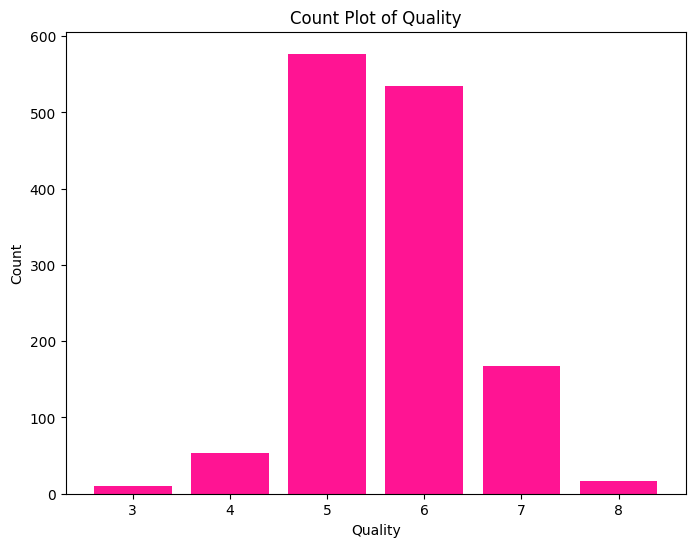

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,4


In [113]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load raw file with ; separator
df = pd.read_csv('winequality-red.csv', sep=';')

# 2. Fix headers: remove quotes, KEEP SPACES for GitHub table
df.columns = df.columns.str.strip().str.replace('"', '')

# 3. Remove duplicates and add Id
df = df.drop_duplicates()
df['Id'] = range(len(df))

# 4. Set column order - with SPACES to match your headers
col_order = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
             'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
             'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']

df = df[col_order] # reorder columns

# 5. Sanity check
print("Shape:", df.shape) # Should be (1359, 13)
print("Columns:", df.columns.tolist())

# 6. Plot quality
quality_counts = df['quality'].value_counts().sort_index()

plt.figure(figsize=(8,6))
plt.bar(quality_counts.index, quality_counts.values, color='deeppink')
plt.title('Count Plot of Quality')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()

# 7. Save as NEW file name with comma separator for GitHub
df.to_csv('winequalityred.csv', index=False) # NOT winequality-red.csv

# 8. Verify
df.head()


In [100]:
# Step 3: Analyzing the Data

df.duplicated().sum()

np.int64(0)

In [101]:
# Basic Information
df.info()

<class 'pandas.DataFrame'>
Index: 1359 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         1359 non-null   float64
 1   volatile_acidity      1359 non-null   float64
 2   citric_acid           1359 non-null   float64
 3   residual_sugar        1359 non-null   float64
 4   chlorides             1359 non-null   float64
 5   free_sulfur_dioxide   1359 non-null   float64
 6   total_sulfur_dioxide  1359 non-null   float64
 7   density               1359 non-null   float64
 8   pH                    1359 non-null   float64
 9   sulphates             1359 non-null   float64
 10  alcohol               1359 non-null   float64
 11  quality               1359 non-null   int64  
 12  Id                    1359 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 148.6 KB


In [102]:
#  Statistical Summary
df.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,Id
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.310596,0.529478,0.272333,2.523400,0.088124,15.893304,46.825975,0.996709,3.309787,0.658705,10.432315,5.623252,679.000000
std,1.736990,0.183031,0.195537,1.352314,0.049377,10.447270,33.408946,0.001869,0.155036,0.170667,1.082065,0.823578,392.453819
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000,339.500000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000,679.000000
75%,9.200000,0.640000,0.430000,2.600000,0.091000,21.000000,63.000000,0.997820,3.400000,0.730000,11.100000,6.000000,1018.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1358.000000


In [103]:
# Check Missing Values
df.isnull().sum()

fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [104]:
#  Shape of Dataset
df.shape

(1359, 13)

Original Shape: (1599, 12)
Shape: (1359, 13)
Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']


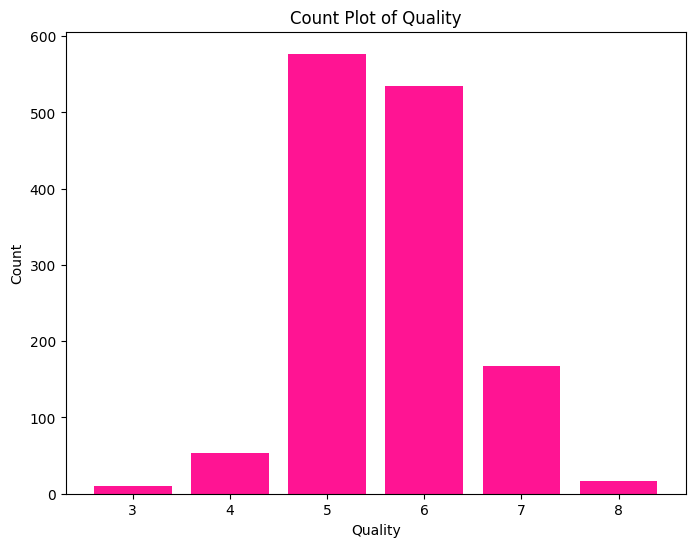

In [105]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. START FRESH - reload the original file
df = pd.read_csv('winequality-red.csv', sep=';')
print("Original Shape:",df.shape )

# 2. Fix headers: remove quotes, keep spaces like your image
df.columns = df.columns.str.strip().str.replace('"', '')

# 3. Drop duplicates: 1599 → 1359
df = df.drop_duplicates()

# 4. Add Id column
df['Id'] = range(len(df))

# 5. Sanity check - must show (1359, 13)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# 6. Plot works now because 'quality' exists
quality_counts = df['quality'].value_counts().sort_index()

plt.figure(figsize=(8,6))
plt.bar(quality_counts.index, quality_counts.values, color='deeppink')
plt.title('Count Plot of Quality')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()

# 7. Save as table CSV with spaces in headers
df.to_csv('winequalityred.csv', index=False)


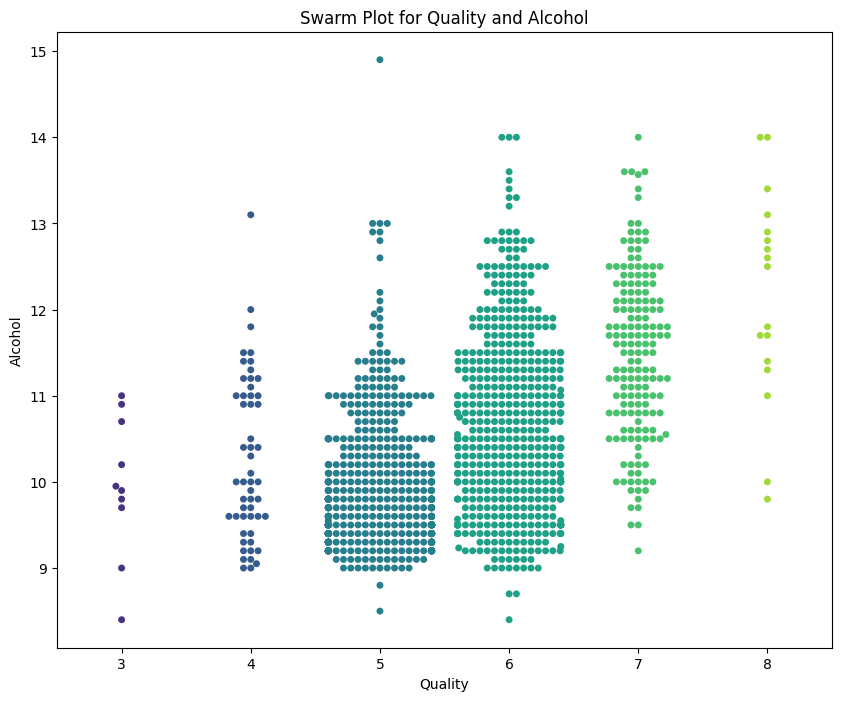

In [106]:
plt.figure(figsize=(10,8))

sns.swarmplot(
    x='quality',
    y='alcohol',
    data=df,
    palette='viridis'
)

plt.title('Swarm Plot for Quality and Alcohol')
plt.xlabel('Quality')
plt.ylabel('Alcohol')

plt.show()

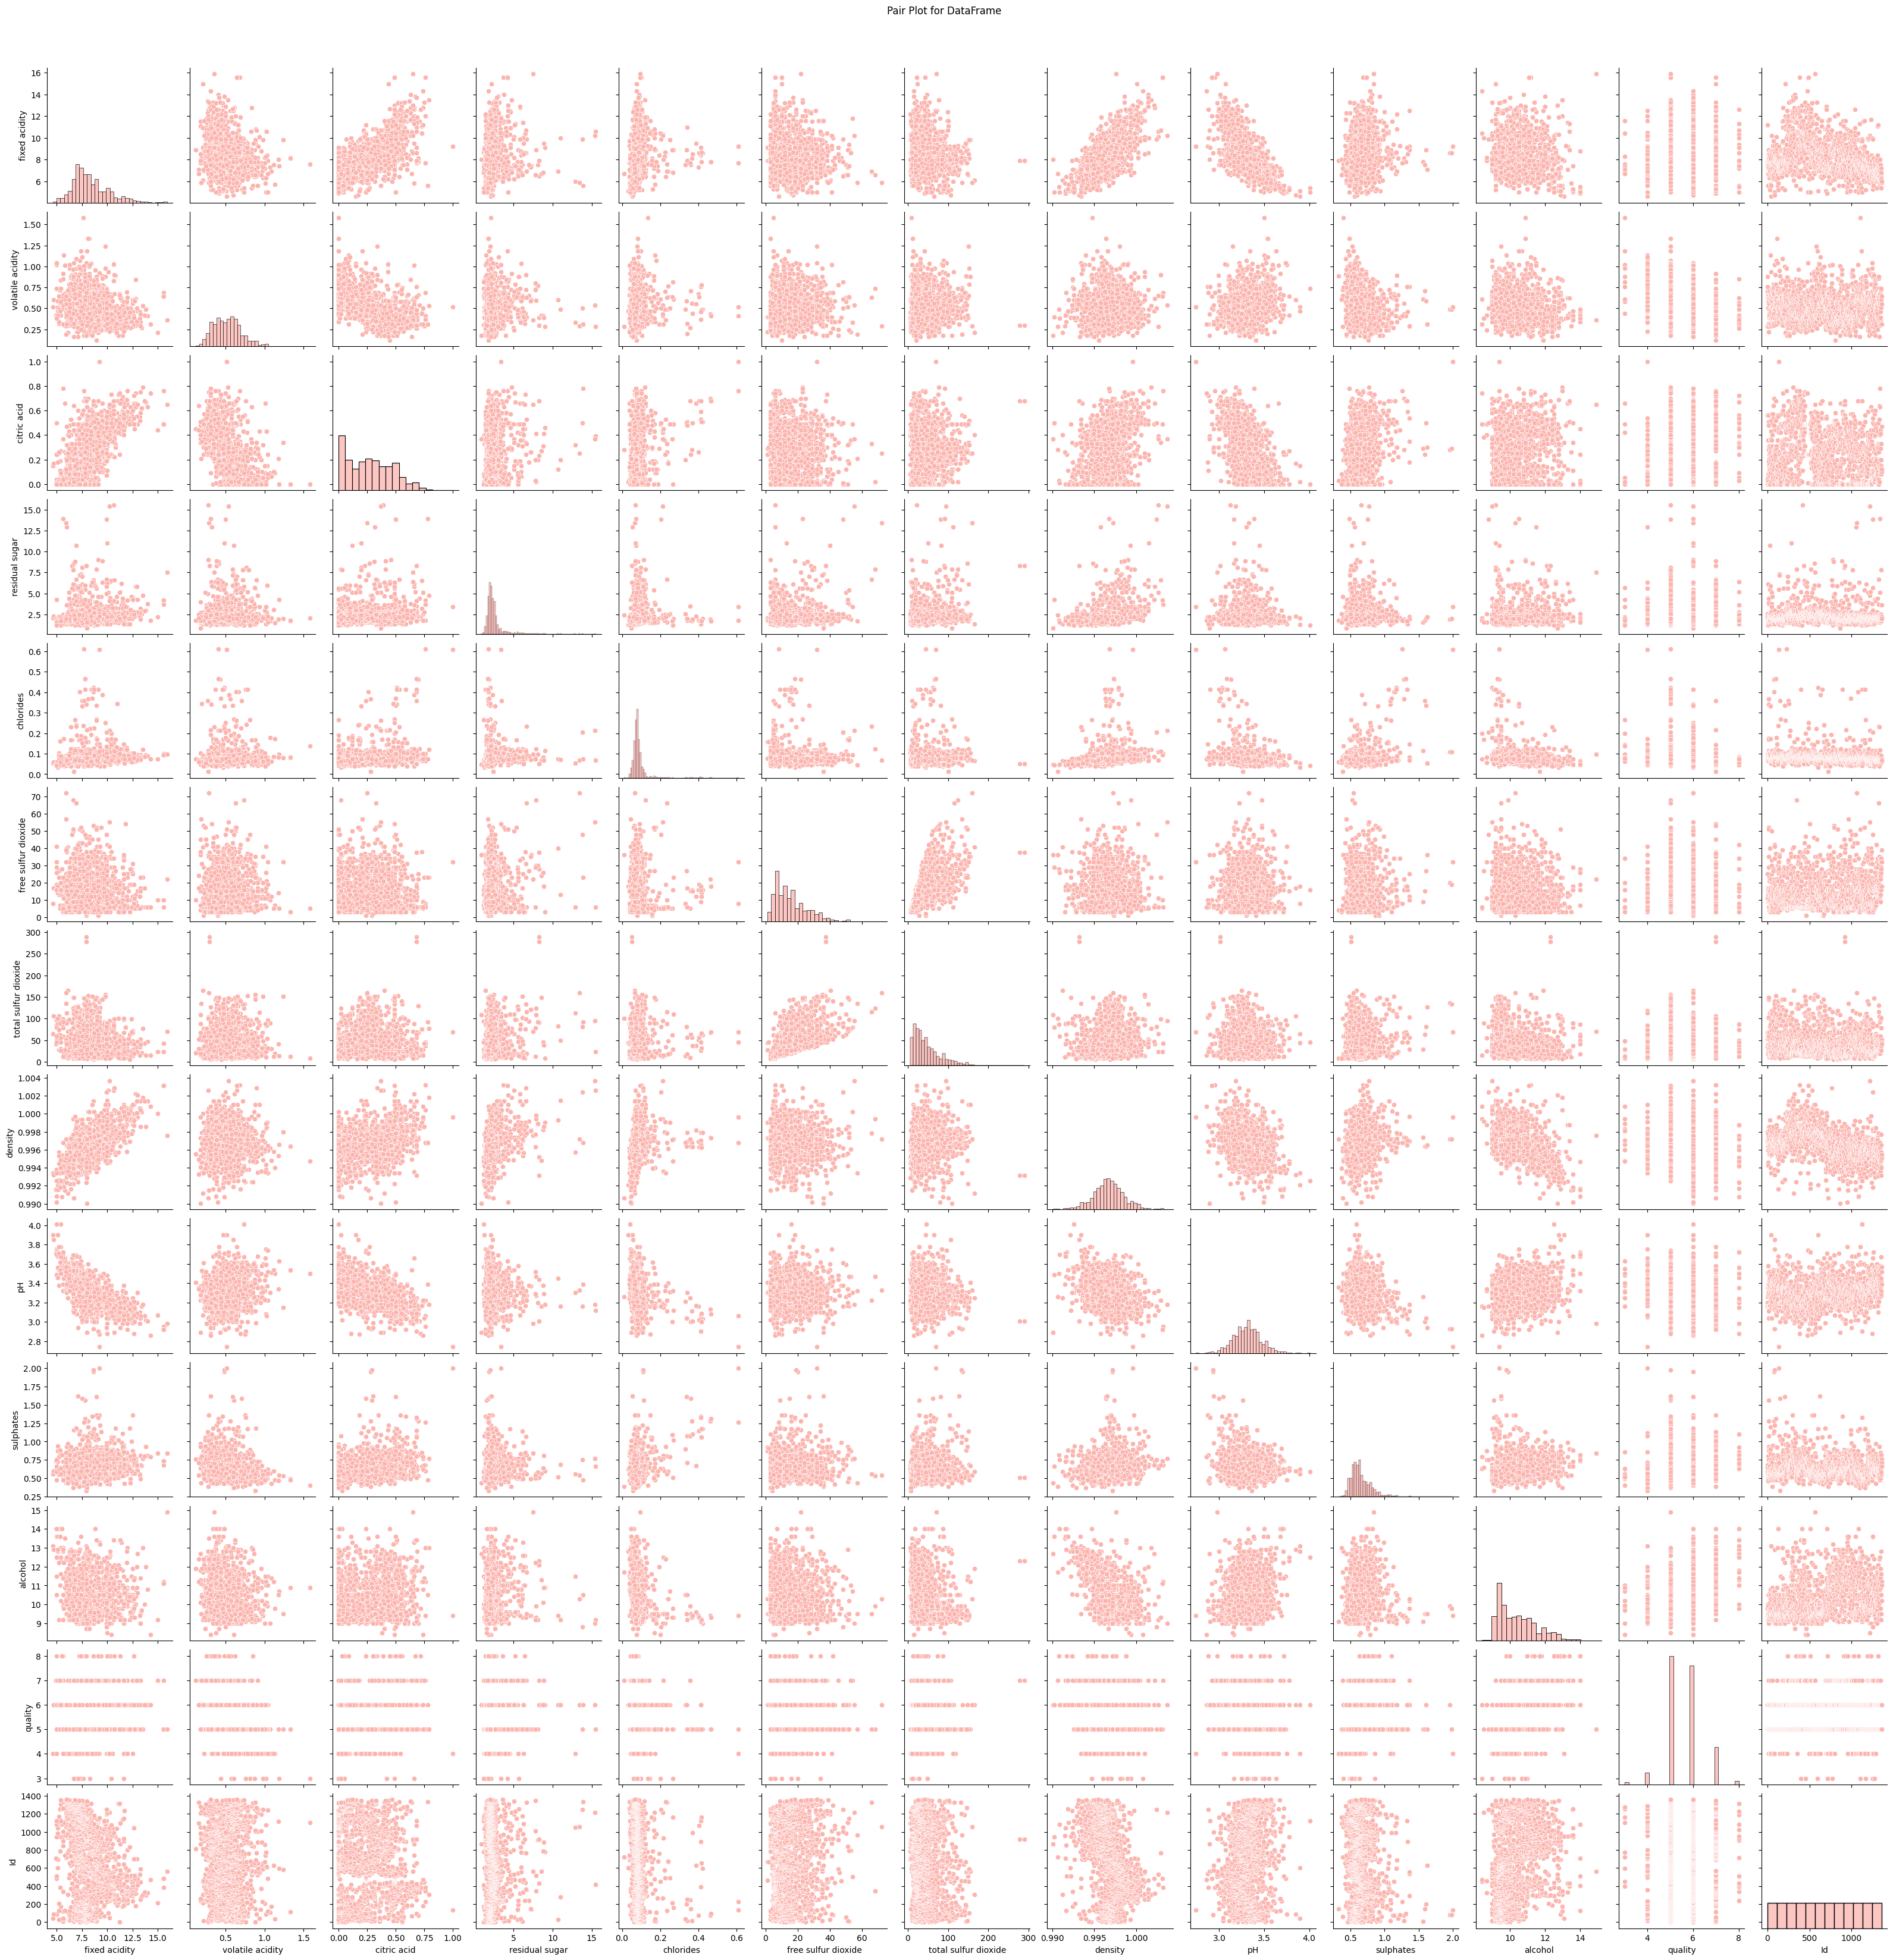

In [107]:
sns.set_palette("Pastel1")

sns.pairplot(df)

plt.suptitle('Pair Plot for DataFrame', y=1.02)

plt.show()

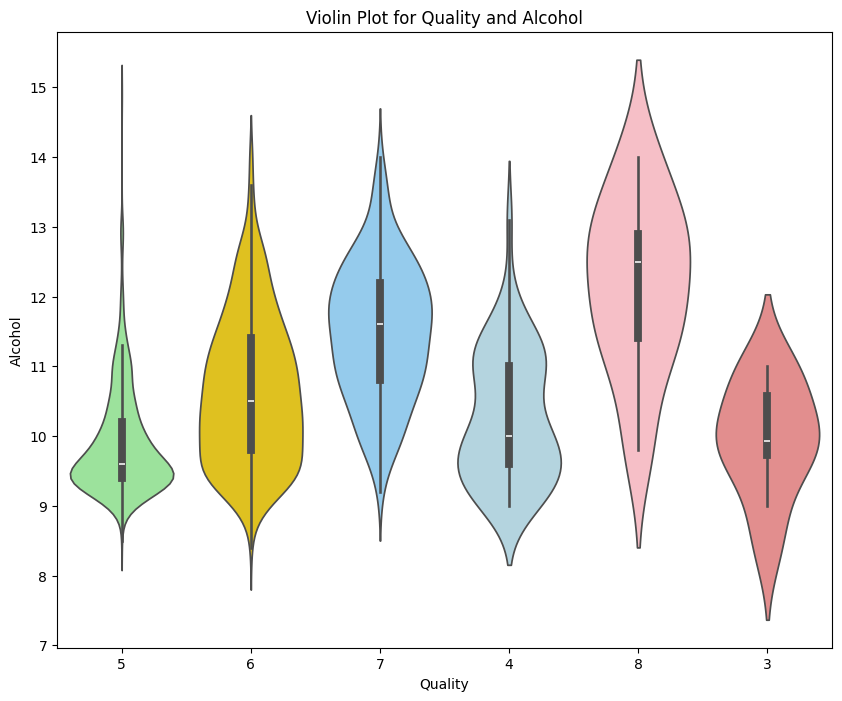

In [108]:
df['quality'] = df['quality'].astype(str)

plt.figure(figsize=(10,8))

sns.violinplot(
    x='quality',
    y='alcohol',
    data=df,
    palette={
        '3':'lightcoral',
        '4':'lightblue',
        '5':'lightgreen',
        '6':'gold',
        '7':'lightskyblue',
        '8':'lightpink'
    }
)

plt.title('Violin Plot for Quality and Alcohol')
plt.xlabel('Quality')
plt.ylabel('Alcohol')

plt.show()

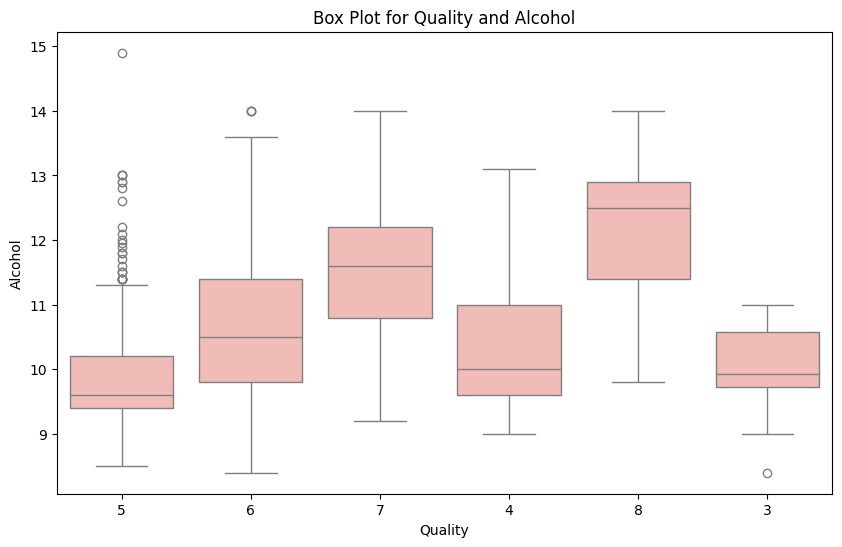

In [109]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='quality',
    y='alcohol',
    data=df
)

plt.title('Box Plot for Quality and Alcohol')
plt.xlabel('Quality')
plt.ylabel('Alcohol')

plt.show()

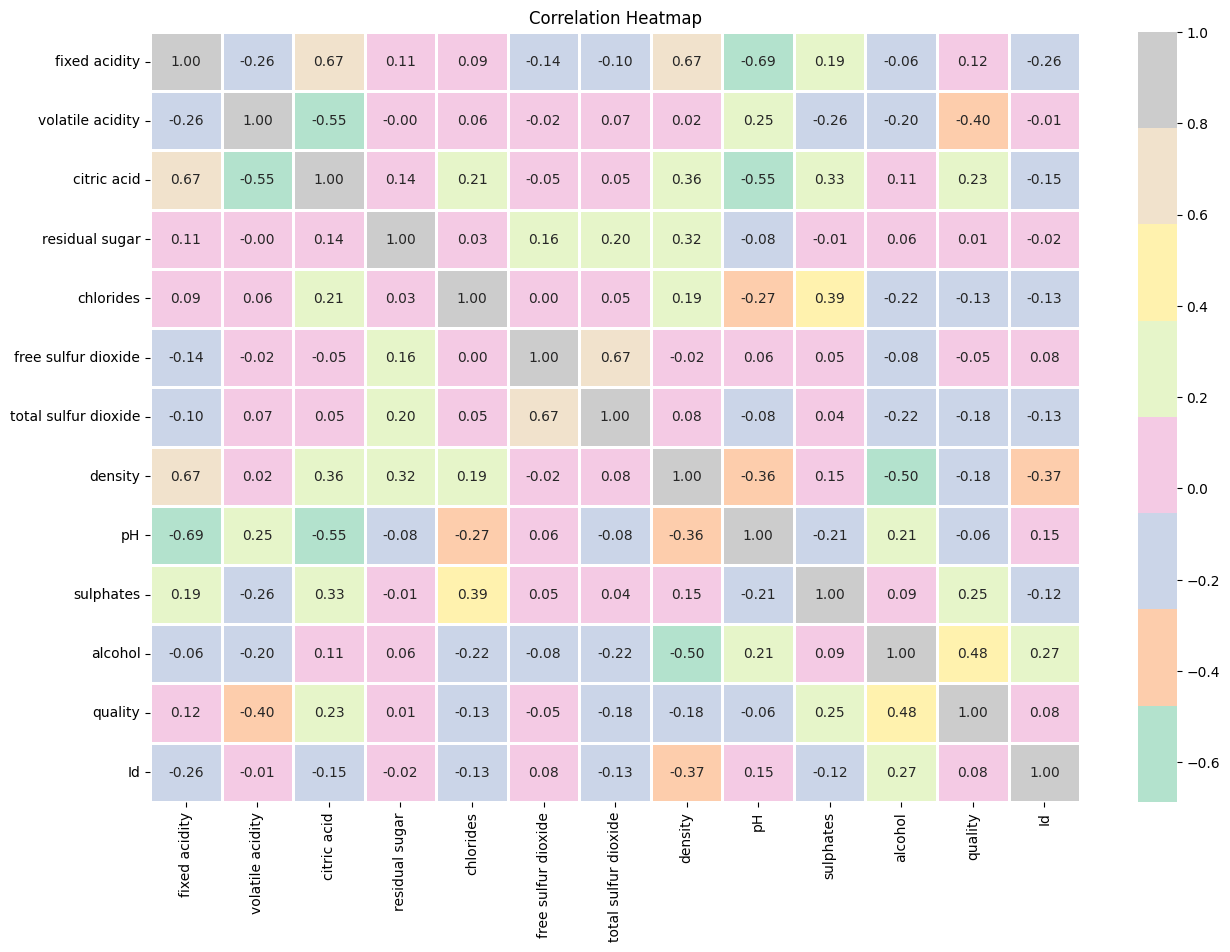

In [110]:
df['quality'] = df['quality'].astype(int)

plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f',
    cmap='Pastel2',
    linewidths=2
)

plt.title('Correlation Heatmap')

plt.show()

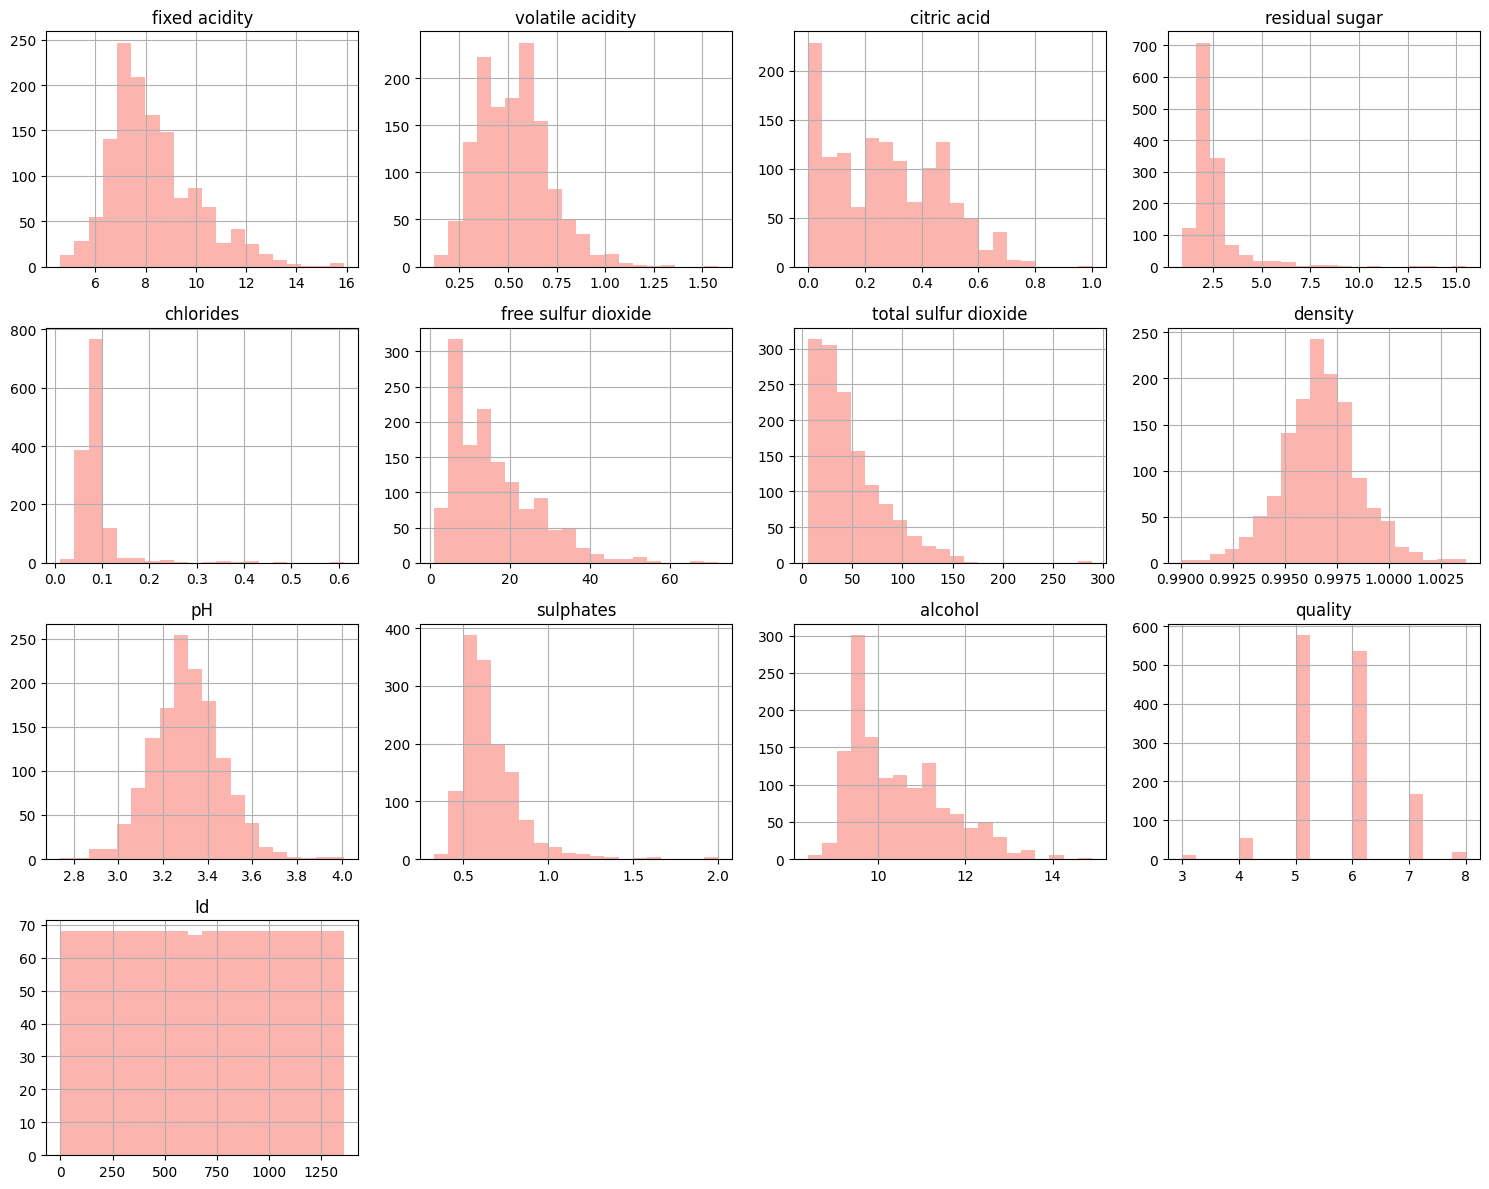

In [111]:
df.hist(
    figsize=(15,12),
    bins=20
)

plt.tight_layout()

plt.show()

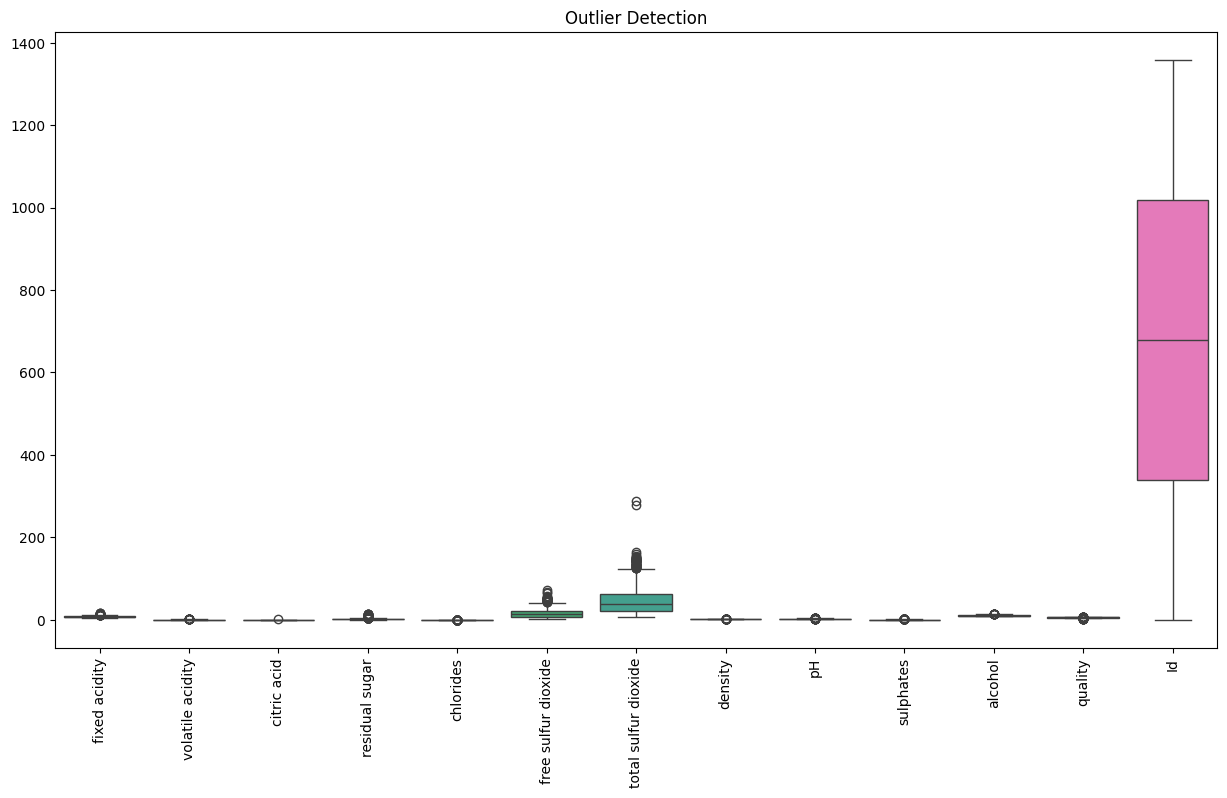

In [112]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.title('Outlier Detection')

plt.show()